In this notebook, we compare multiple loss functions to find train good models for the jaguar reidentification. We use DINOv3 as backbone. After embedding we use a newly trained models using ArcFaceLoss. We compare the identity-based mAP for the validation set, the number of parameters and the training time. The notebooks compares the following loss functions:
1. ArcFace
2. CosFace
3. SphereFace
4. Cross-Entropy
5. Focal Loss

## 1. Setup and Configuration

In [1]:
EXPERIMENT_NAME = "loss"
RANDOM_SEED = 42

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    get_embeddings,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.criterions import ArcFaceLoss
from src.models import EmbeddingProjection
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.training import train_loop
from src.visualization import visualize_embeddings_mds, plot_history

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 42 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    
    # CosFace
    "cosface_margin": 0.35,
    "cosface_scale": 30.0,
    
    # SphereFace
    "sphereface_margin": 4,
    "sphereface_scale": 64.0,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    
    # SubCenterArcFace
    "subcenter_arcface_margin": 0.5,
    "subcenter_arcface_scale": 64.0,
    "subcenter_arcface_num_subcenters": 3,
    
    # BatchHardTriplet
    "batch_hard_triplet_margin": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  arcface_margin: 0.5
  arcface_scale: 64.0
  cosface_margin: 0.35
  cosface_scale: 30.0
  sphereface_margin: 4
  sphereface_scale: 64.0
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  subcenter_arcface_margin: 0.5
  subcenter_arcface_scale: 64.0
  subcenter_arcface_num_subcenters: 3
  batch_hard_triplet_margin: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 42


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


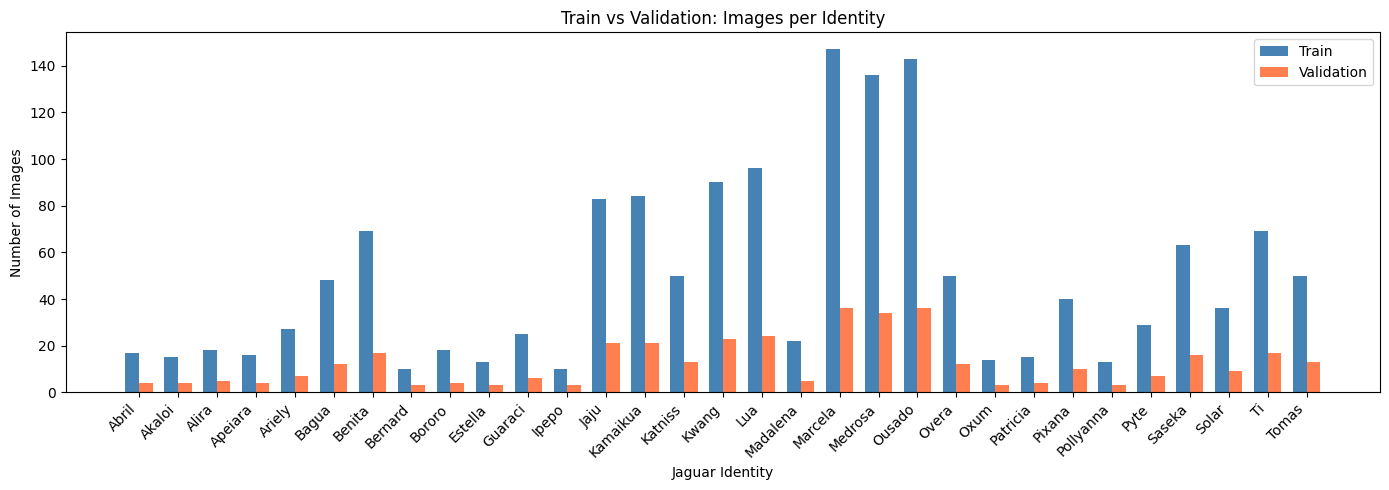


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using num_workers=8 for DataLoader


In [9]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [10]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [11]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [12]:
image_dataset = BlurImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [13]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader,
    filenames,
    device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


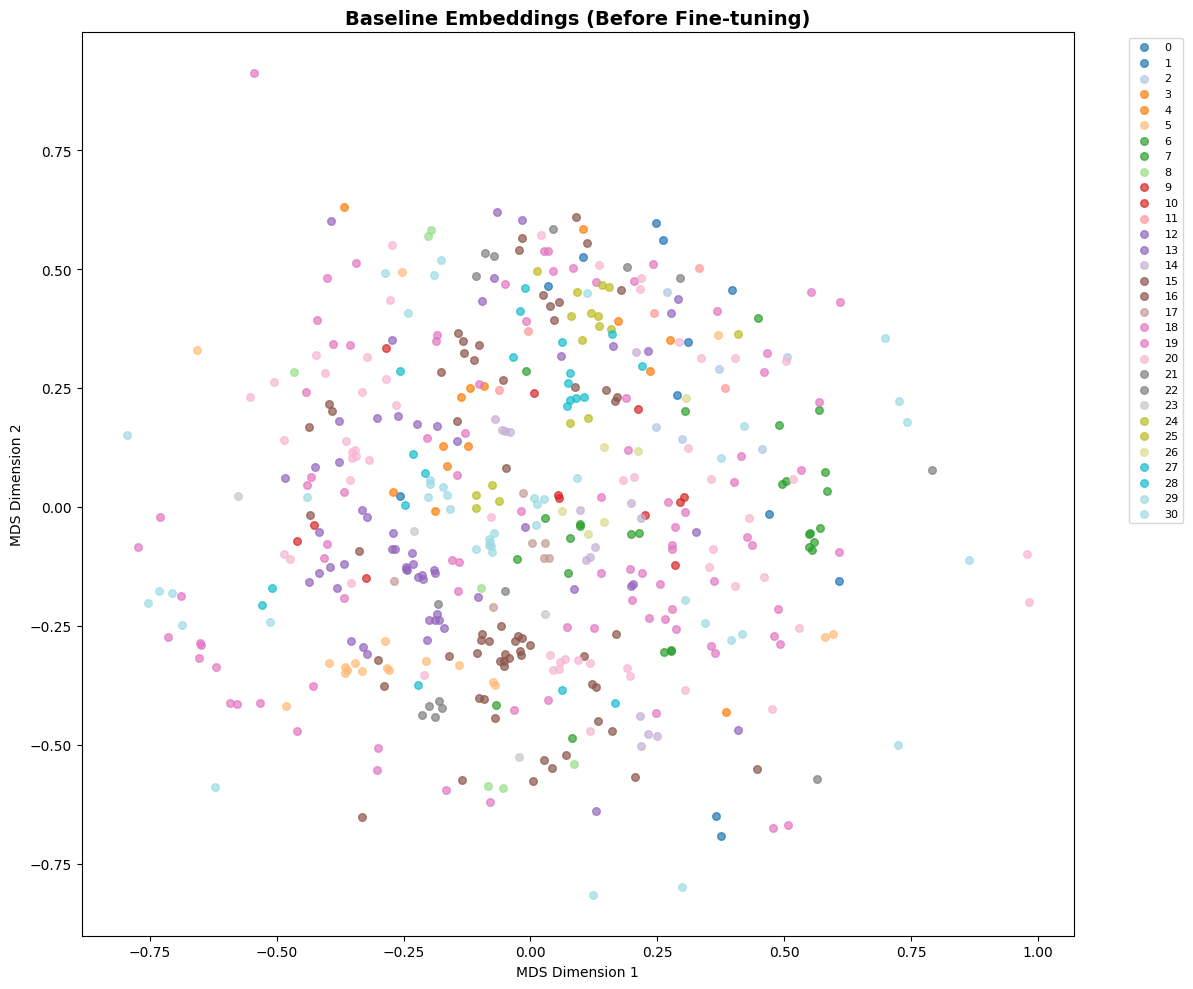

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [16]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


In [17]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/model_initial_weights.pth


In [18]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch"]
]

## ArcFace

In [19]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
ArcFace Loss:
  Embedding dim: 256
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0


In [20]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_arcface_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="arcface",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist(),
)

wandb.log({
    "final_val_mAP_arcface": best_map,
    "best_epoch_arcface": best_epoch,
    "total_epochs_arcface": len(history['train_loss']),
})

table.append([
    "ArcFace",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.8586
  Val Loss:   32.5557
  Val mAP:    0.3468 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.2169
  Val Loss:   28.0986
  Val mAP:    0.3601 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.7384
  Val Loss:   24.7162
  Val mAP:    0.3808 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.8724
  Val Loss:   21.7898
  Val mAP:    0.4055 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.3480
  Val Loss:   3.6311
  Val mAP:    0.8054 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 97/200


  Train Loss: 0.3022
  Val Loss:   3.6416
  Val mAP:    0.8049 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 98/200


  Train Loss: 0.2246
  Val Loss:   3.6353
  Val mAP:    0.8048 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 99/200


  Train Loss: 0.2620
  Val Loss:   3.6969
  Val mAP:    0.8073 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 100/200


  Train Loss: 0.2184
  Val Loss:   3.7741
  Val mAP:    0.8044 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 100 epochs

Training complete!
Best epoch: 90, Val mAP: 0.8101


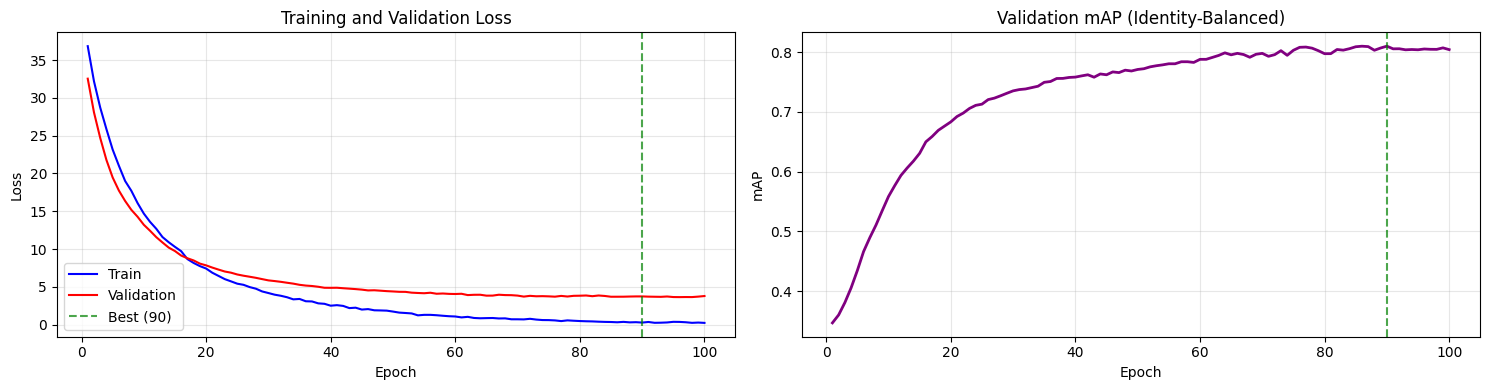

In [21]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_arcface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_arcface": wandb.Image(fig)})

In [22]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_arcface_model.pth
  Val Loss: 3.7230
  Val mAP: 0.8101


In [23]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


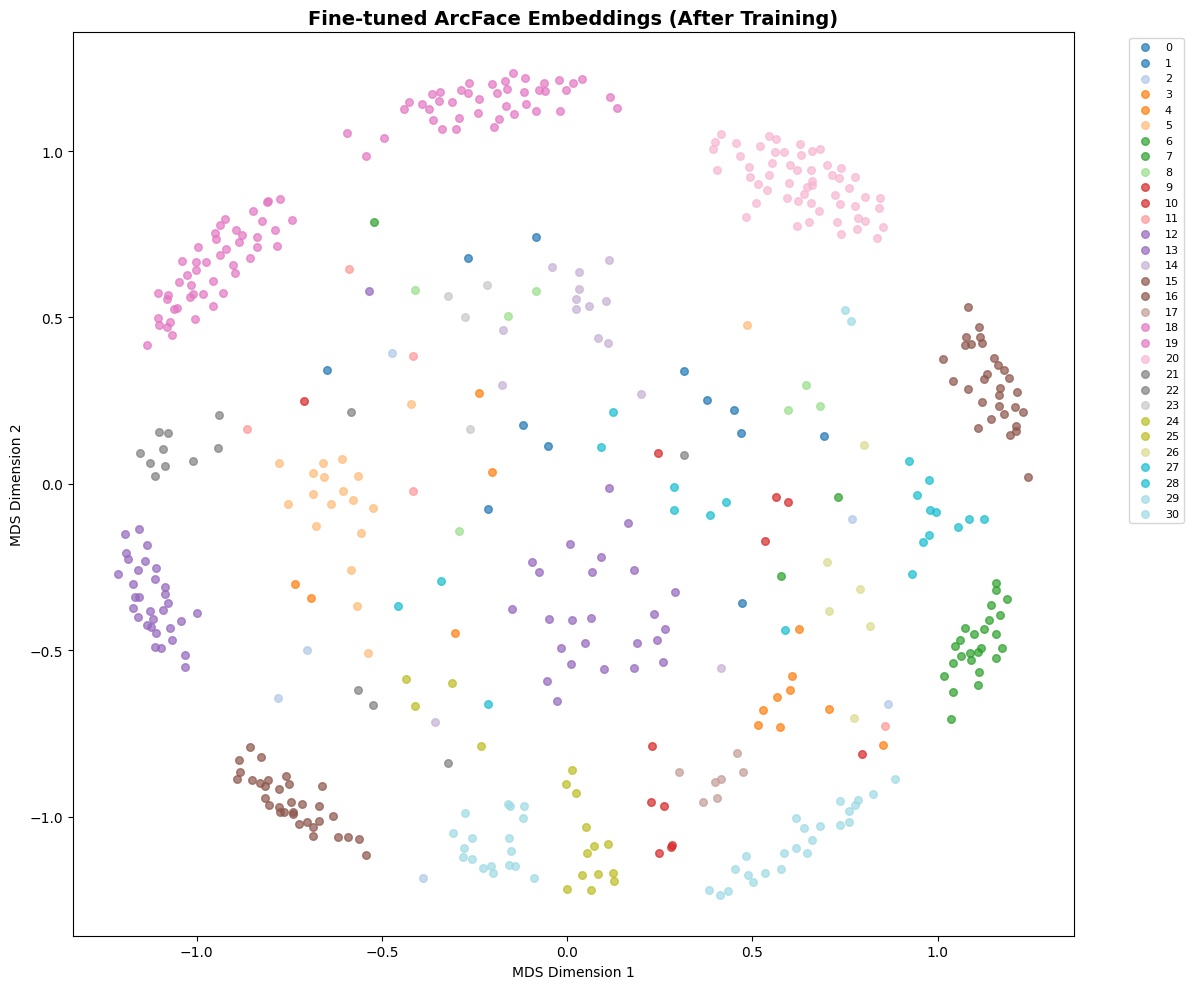

In [24]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "arcface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_arcface": wandb.Image(fig_finetuned)})

In [25]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## CosFace

In [26]:

class CosFaceLoss(nn.Module):
    """
    TODO: Implement
    CosFace (Additive Angular Margin Loss) layer.

    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # One-hot encode labels
        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()
        cosine_m = cosine - one_hot * self.margin
        
        # Scale logits
        logits = cosine_m * self.scale
        loss = F.cross_entropy(logits, labels)

        return loss

print(f"CosFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  CosFace margin: {config['cosface_margin']}")
print(f"  CosFace scale: {config['cosface_scale']}")

CosFace Loss:
  Embedding dim: 256
  Num classes: 31
  CosFace margin: 0.35
  CosFace scale: 30.0


In [27]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CosFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CosFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [28]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_cosface_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="cosface",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist(),
)

wandb.log({
    "final_val_mAP_cosface": best_map,
    "best_epoch_cosface": best_epoch,
    "total_epochs_cosface": len(history['train_loss']),
})

table.append([
    "CosFace",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.2636
  Val Loss:   31.8772
  Val mAP:    0.3491 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.7322
  Val Loss:   27.5015
  Val mAP:    0.3628 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.3572
  Val Loss:   24.1474
  Val mAP:    0.3840 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.5121
  Val Loss:   21.5304
  Val mAP:    0.4097 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.5665
  Val Loss:   3.7403
  Val mAP:    0.7941 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 79/200


  Train Loss: 0.5071
  Val Loss:   3.7307
  Val mAP:    0.7991 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 80/200


  Train Loss: 0.4446
  Val Loss:   3.6986
  Val mAP:    0.7997 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 81/200


  Train Loss: 0.3740
  Val Loss:   3.7138
  Val mAP:    0.7992 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 82/200


  Train Loss: 0.4146
  Val Loss:   3.6080
  Val mAP:    0.8045 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 82 epochs

Training complete!
Best epoch: 72, Val mAP: 0.8049


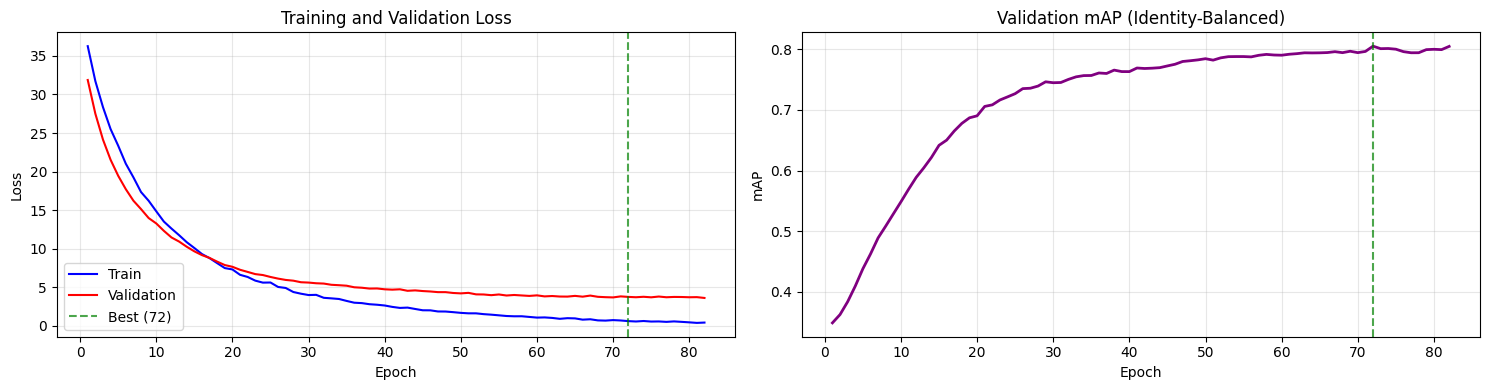

In [29]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_cosface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_cosface": wandb.Image(fig)})

In [30]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_cosface_model.pth
  Val Loss: 3.7439
  Val mAP: 0.8049


In [31]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


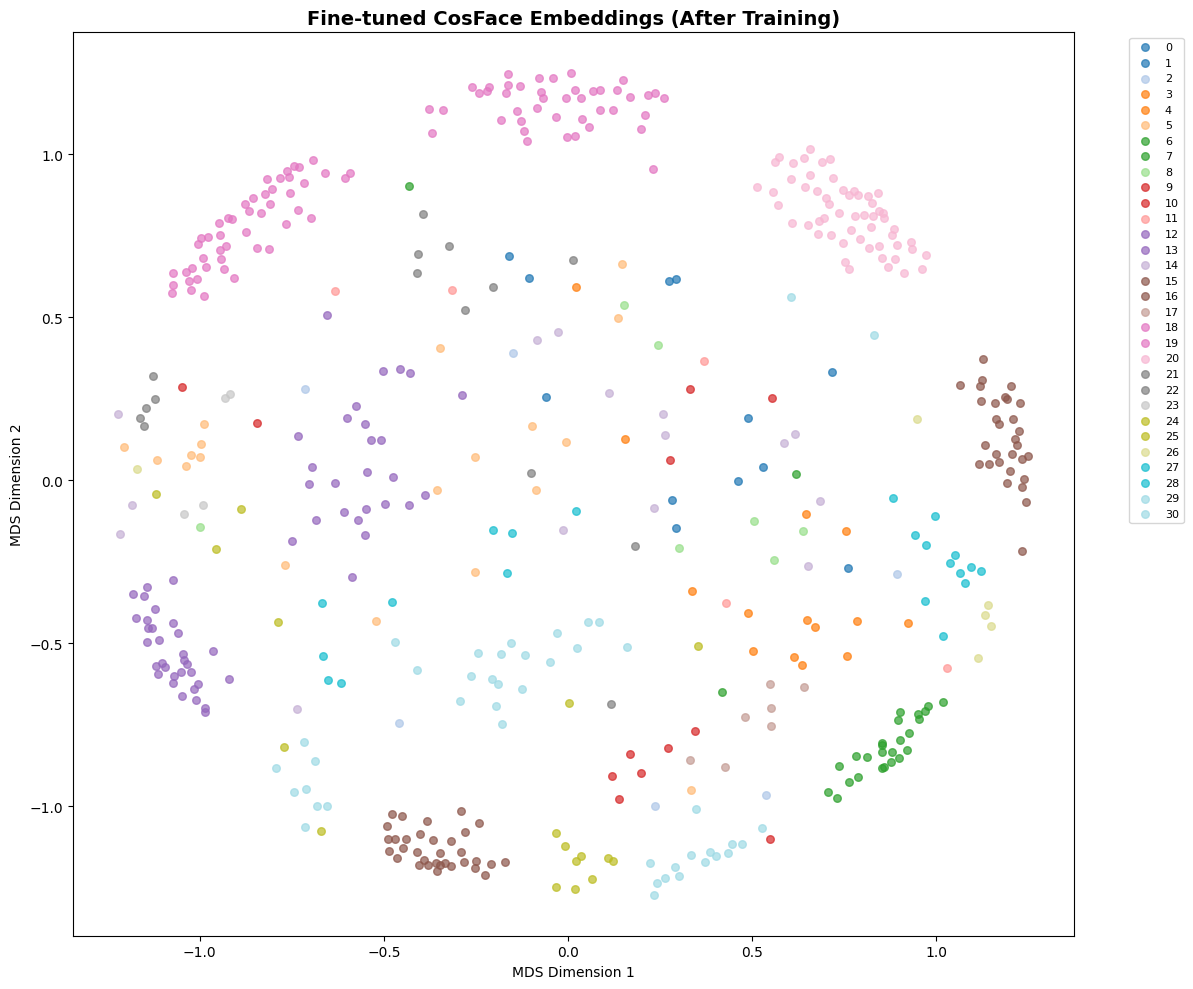

In [32]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned CosFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "cosface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_cosface": wandb.Image(fig_finetuned)})

In [33]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## SphereFace

In [34]:
class SphereFaceLoss(nn.Module):
    """
    SphereFace / A-Softmax Loss

    Paper:
    SphereFace: Deep Hypersphere Embedding for Face Recognition
    https://arxiv.org/abs/1704.08063

    L = -log( exp(s * cos(m * theta_y)) /
              (exp(s * cos(m * theta_y)) + sum_j exp(s * cos(theta_j))) )
    """

    def __init__(self, embedding_dim, num_classes, margin=4, scale=64.0):
        super().__init__()

        assert isinstance(margin, int) and margin >= 1, \
            "SphereFace margin m must be an integer >= 1"

        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.m = margin
        self.s = scale

        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Normalize features and weights
        x = F.normalize(embeddings, dim=1)
        W = F.normalize(self.weight, dim=1)

        # cos(theta)
        cosine = F.linear(x, W).clamp(-1.0, 1.0)

        # cos(m * theta) using Chebyshev polynomials
        cos_m_theta = self._cos_m_theta(cosine)

        # theta = arccos(cos(theta)) (only used to compute k, detached)
        theta = torch.acos(cosine.detach())

        # k = floor(m * theta / pi)
        k = (self.m * theta / math.pi).floor()

        # phi(theta) = (-1)^k * cos(mθ) - 2k
        phi = ((-1.0) ** k) * cos_m_theta - 2 * k

        # One-hot labels
        one_hot = F.one_hot(labels, self.num_classes).float()

        # Replace target logits
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        logits *= self.s

        loss = F.cross_entropy(logits, labels)
        return loss

    def _cos_m_theta(self, cos_theta):
        """
        Compute cos(m * theta) via Chebyshev polynomials.
        """
        if self.m == 1:
            return cos_theta
        elif self.m == 2:
            return 2 * cos_theta**2 - 1
        elif self.m == 3:
            return 4 * cos_theta**3 - 3 * cos_theta
        elif self.m == 4:
            return 8 * cos_theta**4 - 8 * cos_theta**2 + 1
        elif self.m == 5:
            return 16 * cos_theta**5 - 20 * cos_theta**3 + 5 * cos_theta
        else:
            # Recursive Chebyshev (rarely used in practice)
            T0 = torch.ones_like(cos_theta)
            T1 = cos_theta
            for _ in range(2, self.m + 1):
                T2 = 2 * cos_theta * T1 - T0
                T0, T1 = T1, T2
            return T1

print(f"SphereFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SphereFace margin: {config['sphereface_margin']}")
print(f"  SphereFace scale: {config['sphereface_scale']}")

SphereFace Loss:
  Embedding dim: 256
  Num classes: 31
  SphereFace margin: 4
  SphereFace scale: 64.0


In [35]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SphereFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["sphereface_margin"],
    scale=config["sphereface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: SphereFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: SphereFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [36]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_sphereface_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="sphereface",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_sphereface": best_map,
    "best_epoch_sphereface": best_epoch,
    "total_epochs_sphereface": len(history['train_loss']),
})

table.append([
    "SphereFace",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 197.5493
  Val Loss:   190.0261
  Val mAP:    0.3505 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 184.9818
  Val Loss:   167.8193
  Val mAP:    0.3721 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 168.5541
  Val Loss:   152.8878
  Val mAP:    0.3984 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 155.7326
  Val Loss:   142.3121
  Val mAP:    0.4357 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 7.9393
  Val Loss:   19.7050
  Val mAP:    0.8450 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 174/200


  Train Loss: 7.9098
  Val Loss:   19.8734
  Val mAP:    0.8486 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 175/200


  Train Loss: 9.2991
  Val Loss:   19.9357
  Val mAP:    0.8434 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 176/200


  Train Loss: 8.7916
  Val Loss:   19.9434
  Val mAP:    0.8450 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 177/200


  Train Loss: 7.4545
  Val Loss:   20.1333
  Val mAP:    0.8476 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 177 epochs

Training complete!
Best epoch: 167, Val mAP: 0.8515


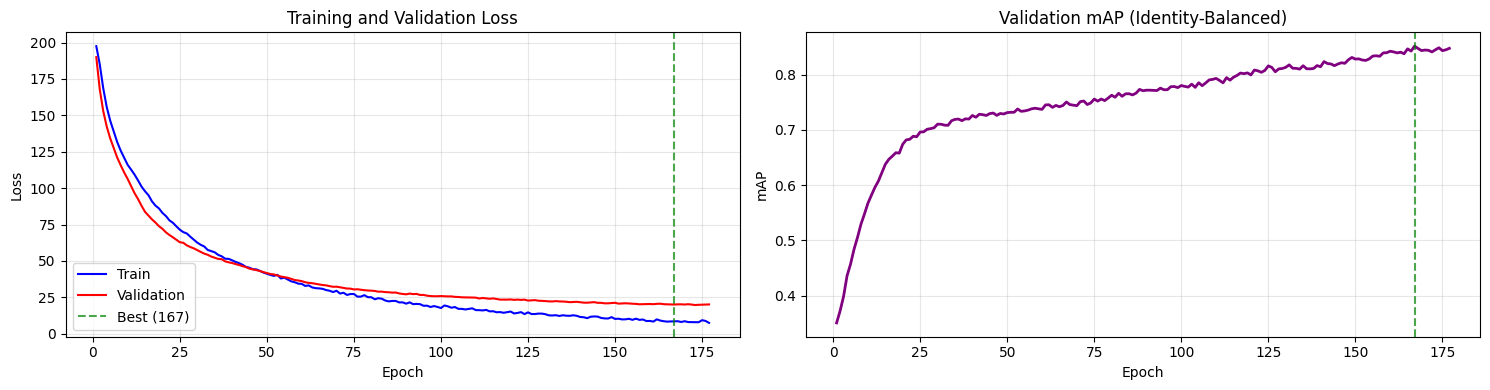

In [37]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sphereface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sphereface": wandb.Image(fig)})

In [38]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_sphereface_model.pth
  Val Loss: 20.0538
  Val mAP: 0.8515


In [39]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


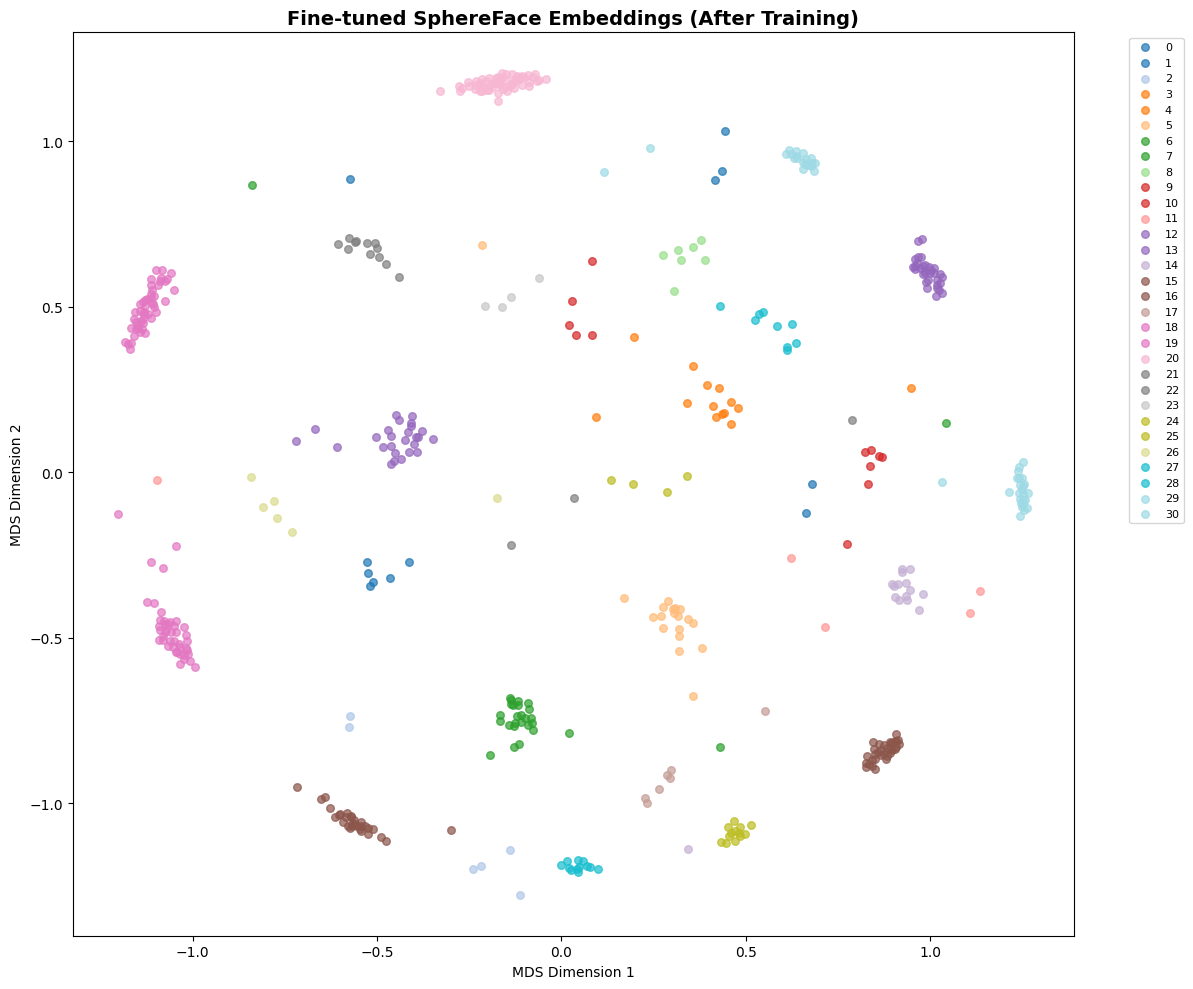

In [40]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SphereFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sphereface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sphereface": wandb.Image(fig_finetuned)})

In [41]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss

In [42]:
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, margin=0.1, alpha=32):
        super().__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')
        self.margin = margin
        self.alpha = alpha

    def forward(self, features, labels):
        features = F.normalize(features)
        proxies = F.normalize(self.proxies)

        sim = F.linear(features, proxies)  # cosine similarity

        pos_mask = F.one_hot(labels, num_classes=sim.size(1)).bool()
        neg_mask = ~pos_mask

        pos_exp = torch.exp(-self.alpha * (sim - self.margin)) * pos_mask
        neg_exp = torch.exp(self.alpha * (sim + self.margin)) * neg_mask

        pos_term = torch.log(1 + pos_exp.sum(dim=0)).sum()
        neg_term = torch.log(1 + neg_exp.sum(dim=0)).sum()

        loss = (pos_term + neg_term) / features.size(0)
        return loss
    
print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

ProxyAnchor Model:
  Embedding dim: 256
  Num classes: 31
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0


In [43]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [44]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_proxyanchor_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
})

table.append([
    "ProxyAnchor",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.9180
  Val Loss:   8.1556
  Val mAP:    0.3437 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.0181
  Val Loss:   7.7773
  Val mAP:    0.3447 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.6008
  Val Loss:   7.5754
  Val mAP:    0.3458 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.3013
  Val Loss:   7.4317
  Val mAP:    0.3476 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.2573
  Val Loss:   0.8820
  Val mAP:    0.8260 | LR: 1.25e-05
  No improvement. Patience: 6/10

Epoch 131/200


  Train Loss: 0.2591
  Val Loss:   0.8800
  Val mAP:    0.8189 | LR: 1.25e-05
  No improvement. Patience: 7/10

Epoch 132/200


  Train Loss: 0.2472
  Val Loss:   0.8923
  Val mAP:    0.8209 | LR: 1.25e-05
  No improvement. Patience: 8/10

Epoch 133/200


  Train Loss: 0.2471
  Val Loss:   0.8817
  Val mAP:    0.8253 | LR: 1.25e-05
  No improvement. Patience: 9/10

Epoch 134/200


  Train Loss: 0.2469
  Val Loss:   0.8728
  Val mAP:    0.8248 | LR: 1.25e-05
  No improvement. Patience: 10/10

Early stopping triggered after 134 epochs

Training complete!
Best epoch: 124, Val mAP: 0.8263


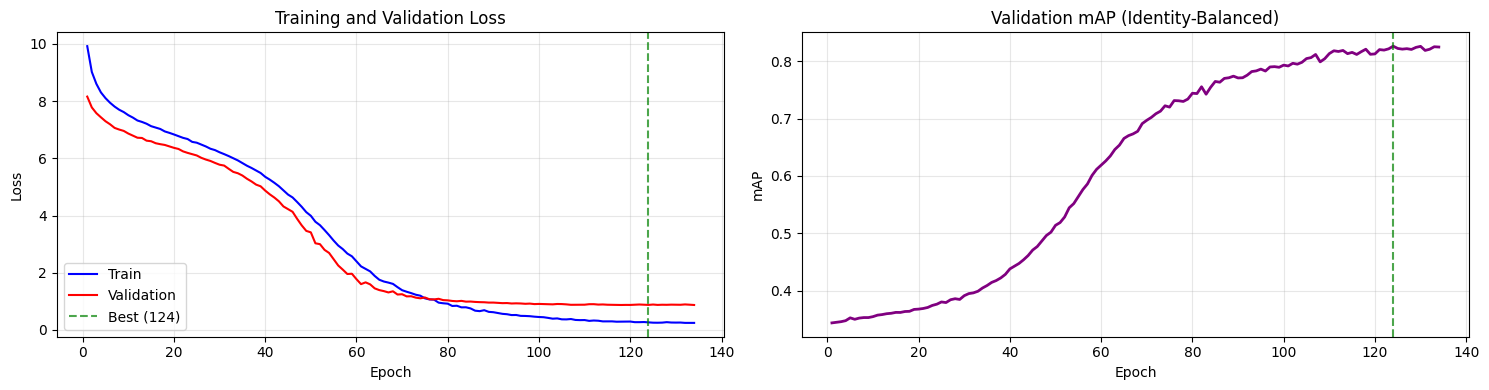

In [45]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [46]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)   
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_proxyanchor_model.pth
  Val Loss: 0.8752
  Val mAP: 0.8263


In [47]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


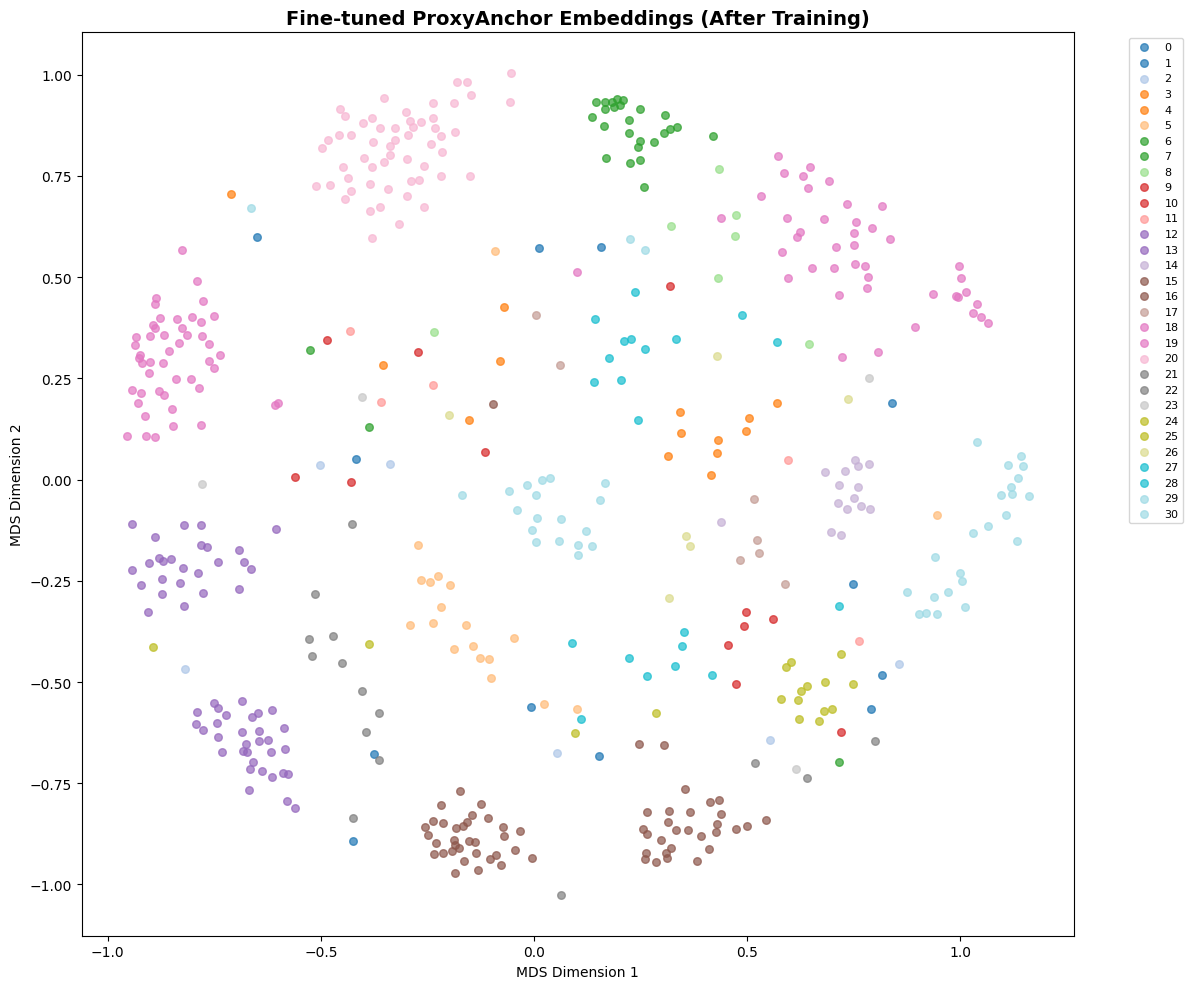

In [48]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [49]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Sub-Center ArcFace

In [50]:
class SubCenterArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, k=3, scale=30.0, margin=0.50):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.k = k
        self.num_classes = num_classes

        self.weight = nn.Parameter(
            torch.randn(num_classes * k, embedding_dim)
        )
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels):
        features = F.normalize(features)
        weight = F.normalize(self.weight)

        cosine = F.linear(features, weight)
        cosine = cosine.view(-1, self.num_classes, self.k)

        cosine, _ = cosine.max(dim=2)  # pick closest sub-center

        theta = torch.acos(torch.clamp(cosine, -1 + 1e-7, 1 - 1e-7))
        target_cosine = torch.cos(theta + self.margin)

        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()

        logits = cosine * (1 - one_hot) + target_cosine * one_hot
        logits *= self.scale
        loss = F.cross_entropy(logits, labels)
    
        return loss


print(f"SubCenterArcFace Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SubCenterArcFace k: {config['subcenter_arcface_num_subcenters']}")
print(f"  SubCenterArcFace margin: {config['subcenter_arcface_margin']}")
print(f"  SubCenterArcFace scale: {config['subcenter_arcface_scale']}")

SubCenterArcFace Model:
  Embedding dim: 256
  Num classes: 31
  SubCenterArcFace k: 3
  SubCenterArcFace margin: 0.5
  SubCenterArcFace scale: 64.0


In [51]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SubCenterArcFaceLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    k=config["subcenter_arcface_num_subcenters"],
    margin=config["subcenter_arcface_margin"],
    scale=config["subcenter_arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: SubCenterArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: SubCenterArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [52]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_subcenterarcface_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="subcenterarcface",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_subcenterarcface": best_map,
    "best_epoch_subcenterarcface": best_epoch,
    "total_epochs_subcenterarcface": len(history['train_loss']),
})

table.append([
    "SubCenterArcFace",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.1355
  Val Loss:   32.9433
  Val mAP:    0.3446 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.7230
  Val Loss:   29.1558
  Val mAP:    0.3537 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.6855
  Val Loss:   25.8118
  Val mAP:    0.3673 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 26.7214
  Val Loss:   23.0217
  Val mAP:    0.3830 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.3765
  Val Loss:   3.8461
  Val mAP:    0.7199 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 96/200


  Train Loss: 0.2701
  Val Loss:   3.8016
  Val mAP:    0.7179 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 97/200


  Train Loss: 0.3405
  Val Loss:   3.7653
  Val mAP:    0.7203 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 98/200


  Train Loss: 0.2356
  Val Loss:   3.7833
  Val mAP:    0.7193 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 99/200


  Train Loss: 0.2945
  Val Loss:   3.7435
  Val mAP:    0.7215 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 99 epochs

Training complete!
Best epoch: 89, Val mAP: 0.7217


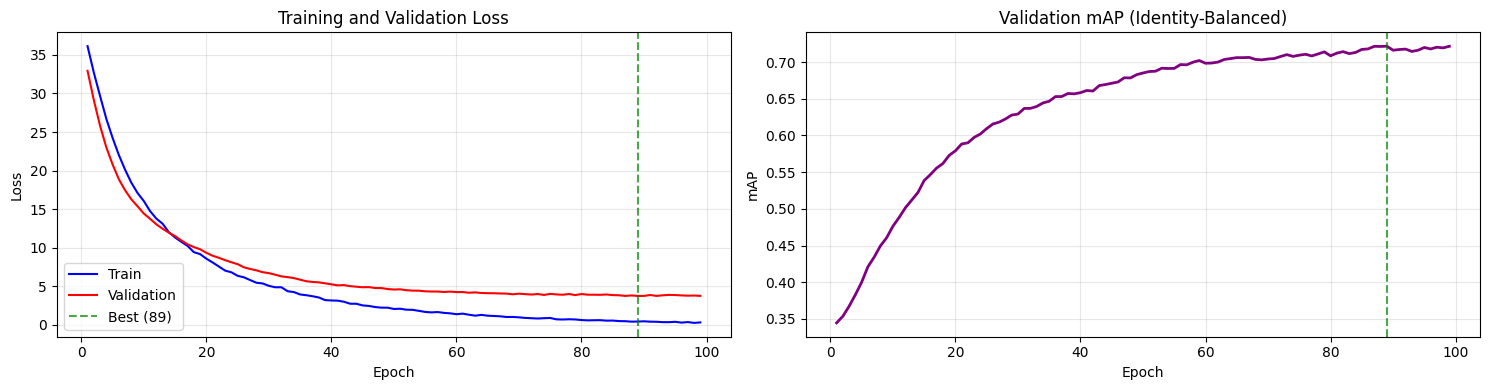

In [53]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sub_center_arc_face.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sub_center_arc_face": wandb.Image(fig)})

In [54]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_subcenterarcface_model.pth
  Val Loss: 3.7276
  Val mAP: 0.7217


In [55]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


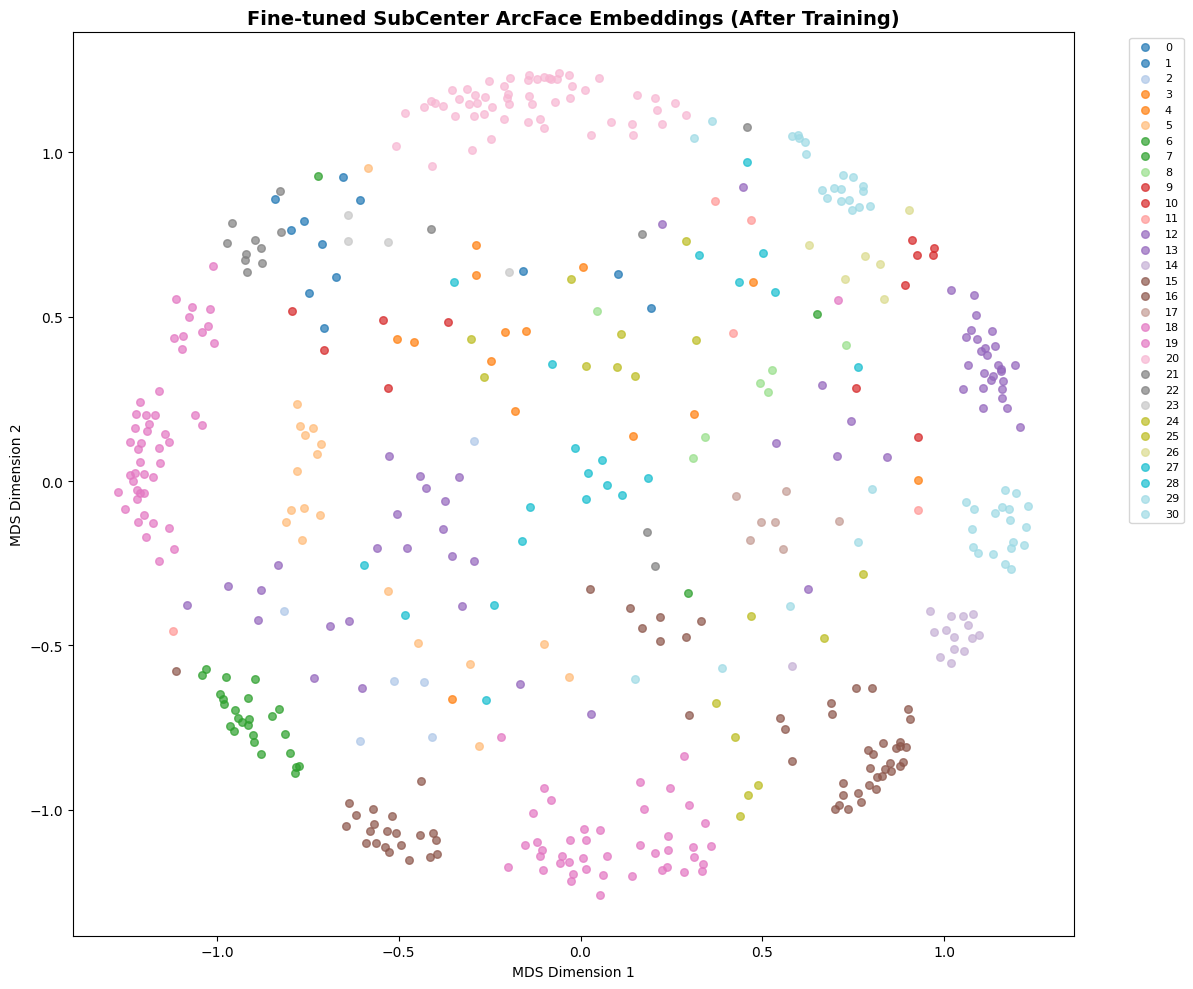

In [56]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SubCenter ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sub_center_arc_face_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sub_center_arc_face": wandb.Image(fig_finetuned)})

In [57]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Center Loss

In [58]:
class CenterLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embedding_dim))

    def forward(self, features, labels):
        centers_batch = self.centers[labels]
        loss = ((features - centers_batch) ** 2).sum(dim=1).mean()
        return loss

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")

Center Loss:
  Embedding dim: 256
  Num classes: 31


In [59]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CenterLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CenterLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CenterLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [60]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_center_loss_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="center_loss",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_center_loss": best_map,
    "best_epoch_center_loss": best_epoch,
    "total_epochs_center_loss": len(history['train_loss']),
})

table.append([
    "Center Loss",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 491.2862
  Val Loss:   372.3135
  Val mAP:    0.3501 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 442.1485
  Val Loss:   336.7608
  Val mAP:    0.3630 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 403.8523
  Val Loss:   308.6802
  Val mAP:    0.3825 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 369.7615
  Val Loss:   282.0630
  Val mAP:    0.4021 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 26.2623
  Val Loss:   31.1206
  Val mAP:    0.8313 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 157/200


  Train Loss: 26.7282
  Val Loss:   31.1336
  Val mAP:    0.8261 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 158/200


  Train Loss: 25.3271
  Val Loss:   30.9666
  Val mAP:    0.8284 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 159/200


  Train Loss: 24.4498
  Val Loss:   31.0679
  Val mAP:    0.8274 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 160/200


  Train Loss: 25.5667
  Val Loss:   30.8126
  Val mAP:    0.8250 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 160 epochs

Training complete!
Best epoch: 150, Val mAP: 0.8332


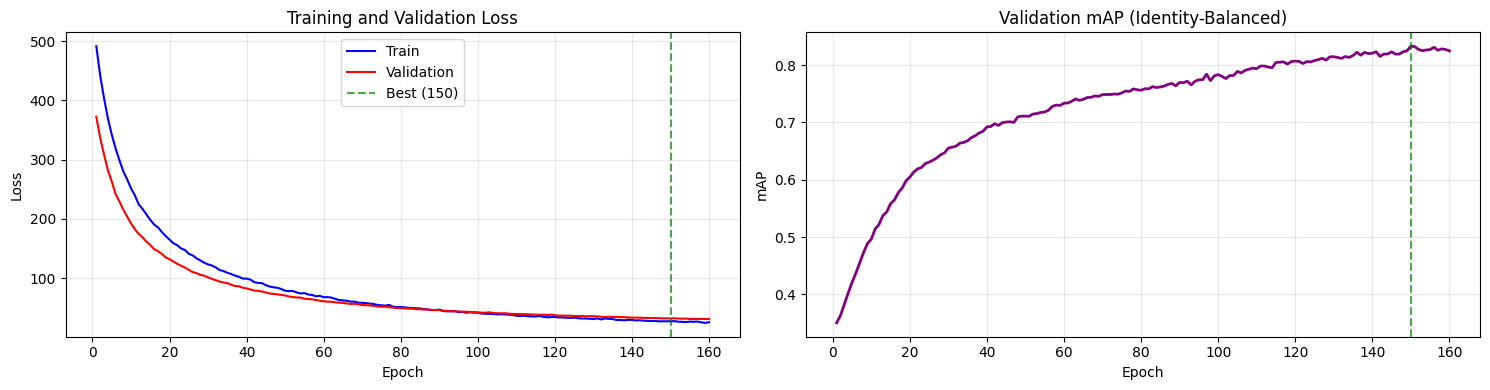

In [61]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center_loss": wandb.Image(fig)})

In [62]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_center_loss_model.pth
  Val Loss: 31.8340
  Val mAP: 0.8332


In [63]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


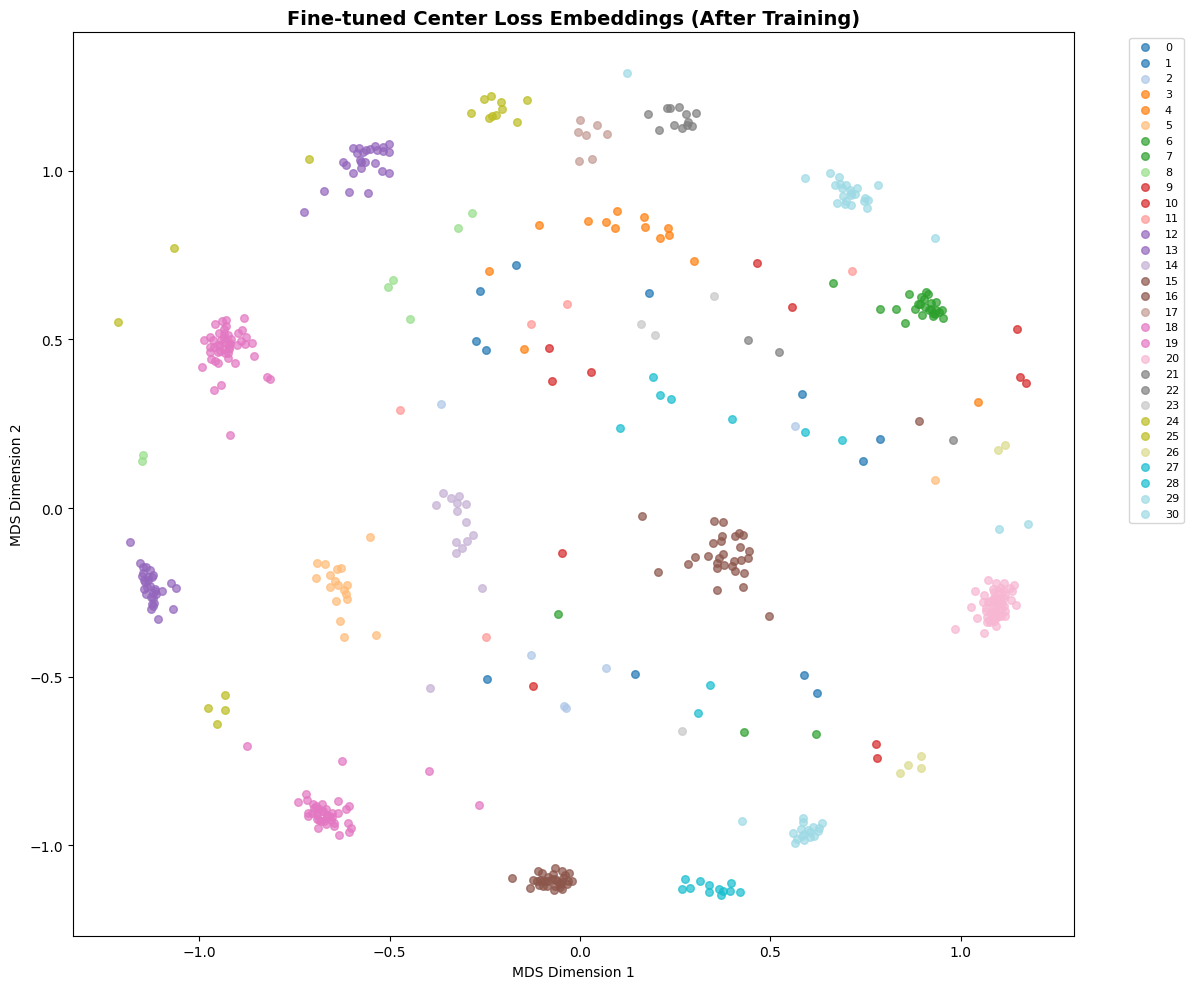

In [64]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center Loss Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_loss_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center_loss": wandb.Image(fig_finetuned)})

In [65]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Batch-Hard Triplet Loss

In [66]:
class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, features, labels):
        features = F.normalize(features)
        dist = torch.cdist(features, features, p=2)

        labels = labels.unsqueeze(1)
        mask_pos = labels.eq(labels.T)
        mask_neg = ~mask_pos

        hardest_pos = (dist * mask_pos.float()).max(dim=1)[0]

        dist_neg = dist.clone()
        dist_neg[~mask_neg] = float('inf')
        hardest_neg = dist_neg.min(dim=1)[0]

        loss = F.relu(hardest_pos - hardest_neg + self.margin)
        return loss.mean()

print(f"Batch Hard Triplet Loss:")
print(f"  Margin: {config['batch_hard_triplet_margin']}")

Batch Hard Triplet Loss:
  Margin: 0.3


In [67]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = BatchHardTripletLoss(
    margin=config["batch_hard_triplet_margin"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: BatchHardTripletLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: BatchHardTripletLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [68]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_batch_hard_triplet_model.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="batch_hard_triplet",
    checkpoint_path=checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_batch_hard_triplet": best_map,
    "best_epoch_batch_hard_triplet": best_epoch,
    "total_epochs_batch_hard_triplet": len(history['train_loss']),
})

table.append([
    "Batch Hard Triplet",
    best_map,
    best_epoch
])

All random seeds set to 42 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 0.3038
  Val Loss:   0.4628
  Val mAP:    0.3760 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 0.2885
  Val Loss:   0.4280
  Val mAP:    0.3994 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 0.2720
  Val Loss:   0.4071
  Val mAP:    0.4230 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 0.2586
  Val Loss:   0.3942
  Val mAP:    0.4405 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.0077
  Val Loss:   0.0794
  Val mAP:    0.7576 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 135/200


  Train Loss: 0.0108
  Val Loss:   0.0779
  Val mAP:    0.7587 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 136/200


  Train Loss: 0.0074
  Val Loss:   0.0791
  Val mAP:    0.7588 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 137/200


  Train Loss: 0.0057
  Val Loss:   0.0793
  Val mAP:    0.7573 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 138/200


  Train Loss: 0.0073
  Val Loss:   0.0781
  Val mAP:    0.7598 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 138 epochs

Training complete!
Best epoch: 128, Val mAP: 0.7606


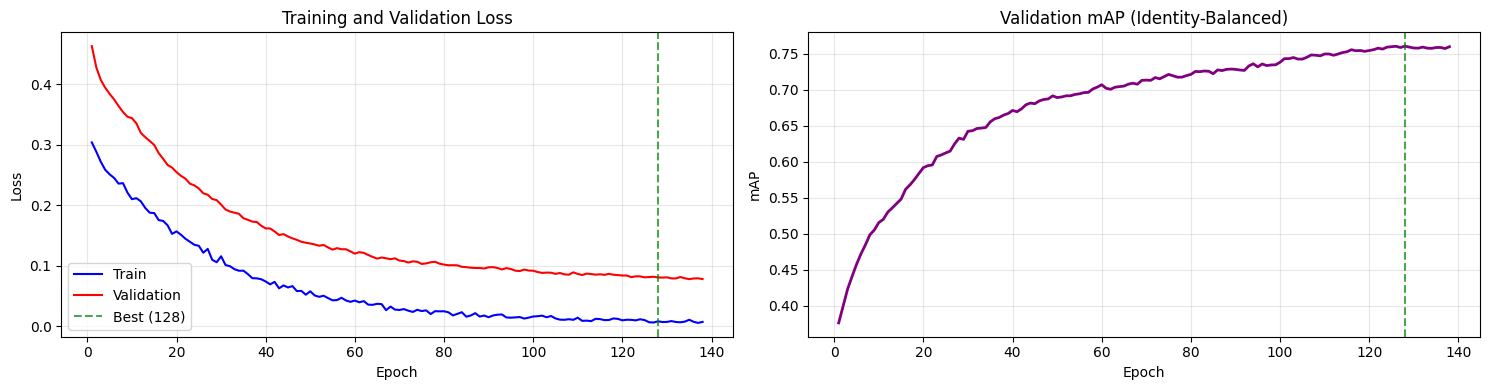

In [69]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_batch_hard_triplet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_batch_hard_triplet": wandb.Image(fig)})

In [70]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint_path}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_batch_hard_triplet_model.pth
  Val Loss: 0.0808
  Val mAP: 0.7606


In [71]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


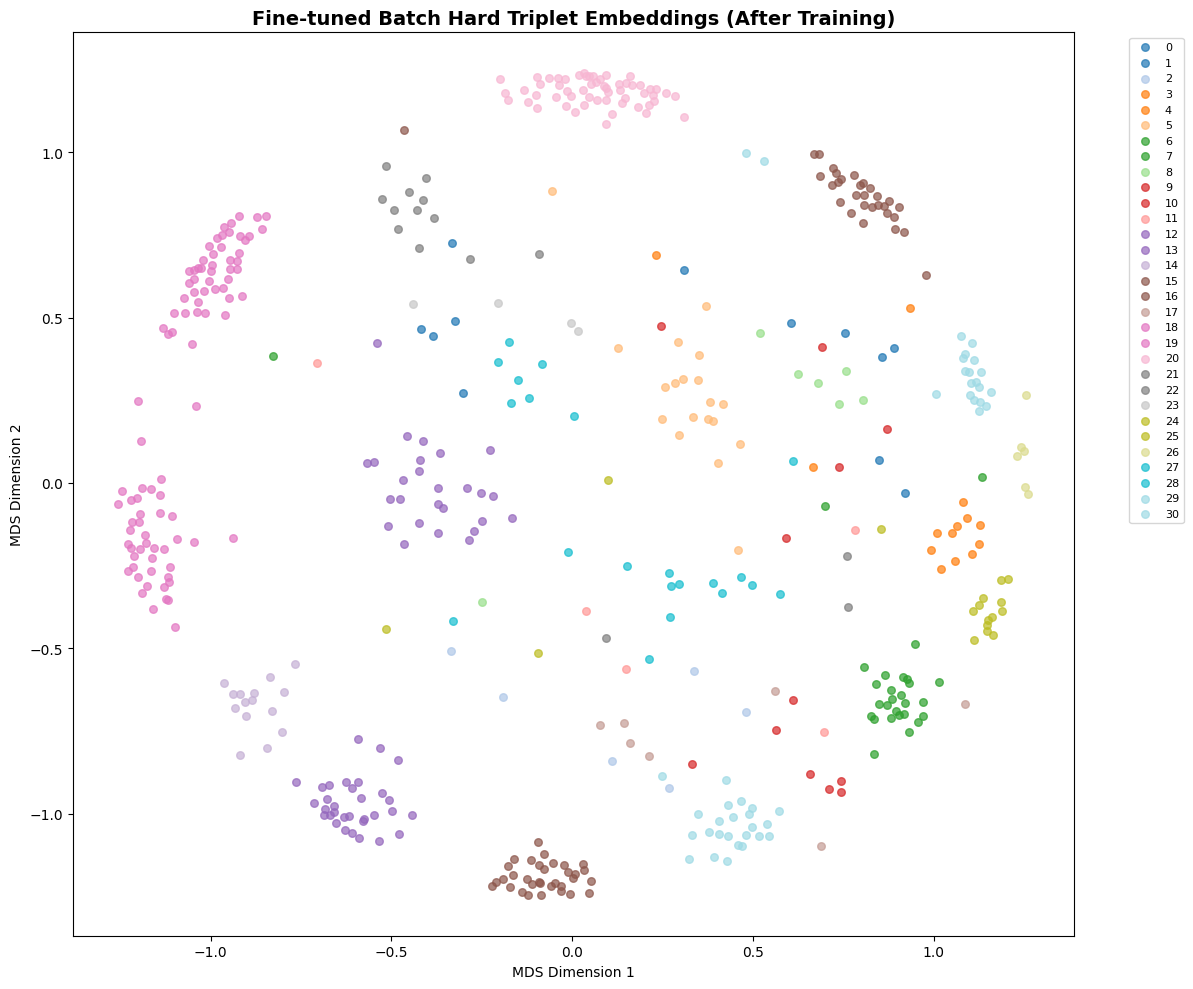

In [72]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Batch Hard Triplet Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "batch_hard_triplet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_batch_hard_triplet": wandb.Image(fig_finetuned)})

In [73]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [74]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
| Loss Function   |   ArcFace |   CosFace |   SphereFace |   ProxyAnchor |   SubCenterArcFace |   Center Loss |   Batch Hard Triplet |
+=================+===========+===========+==============+===============+====================+===============+======================+
| Best val_mAP    |  0.810142 |  0.804853 |     0.851518 |      0.826304 |           0.721676 |      0.833169 |             0.760581 |
+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
| Best epoch      | 90        | 72        |   167        |    124        |          89        |    150        |           128        |
+-----------------+-----------+-----------+--------------+---------------+--------------------+---------------+----------------------+
